In [ ]:
import pandas as pd
import numpy as np
import datetime
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import pathlib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.naive_bayes import ComplementNB, GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score,roc_curve, auc, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('f.csv')


In [2]:
df = df.drop_duplicates().reset_index(drop=True)
print("Пропуски по столбцам:\n", df.isna().sum())


df = df.dropna(subset=['fruit_name']).reset_index(drop=True)


num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']
target_col = 'fruit_name'

Пропуски по столбцам:
 size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64


Найдено классов: 20

=== ComplementNB ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       0.88      1.00      0.94       100
custard apple       0.90      1.00      0.95       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      0.88      0.94       107
         plum       1.

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


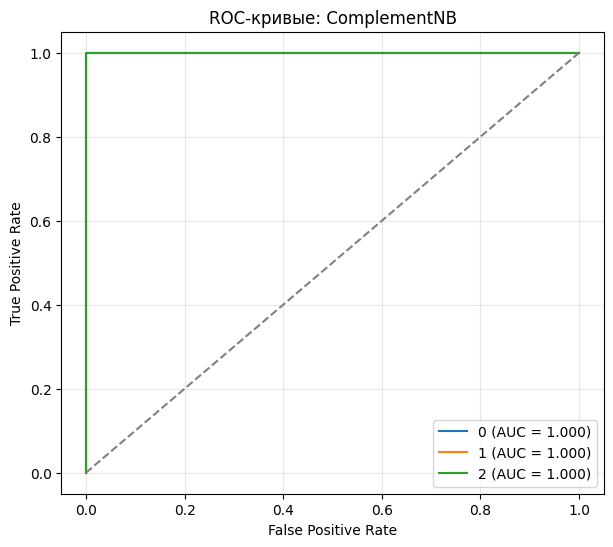

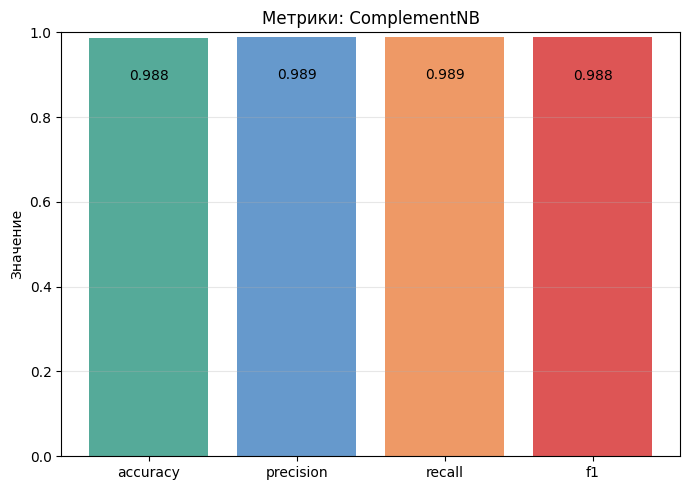


=== GaussianNB ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00      1.00      1.00

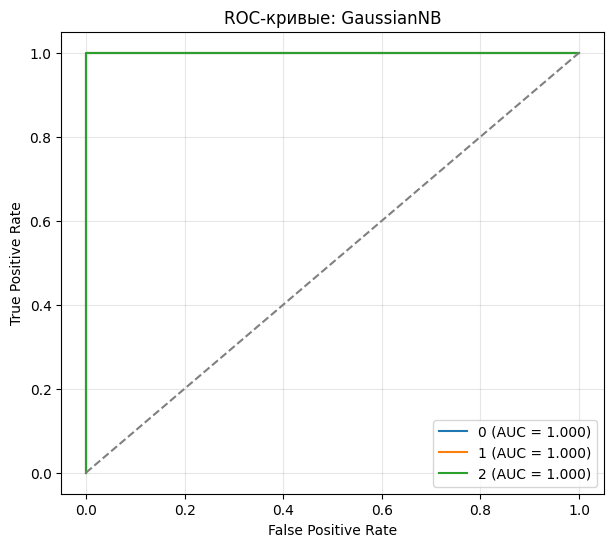

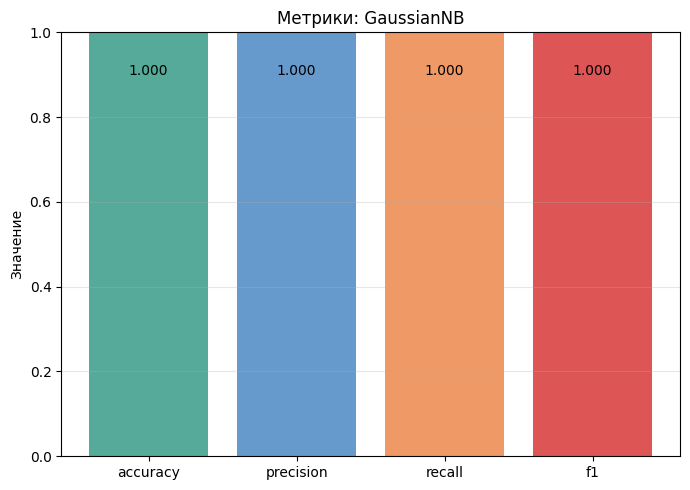


=== MultinomialNB ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00      1.00      1

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


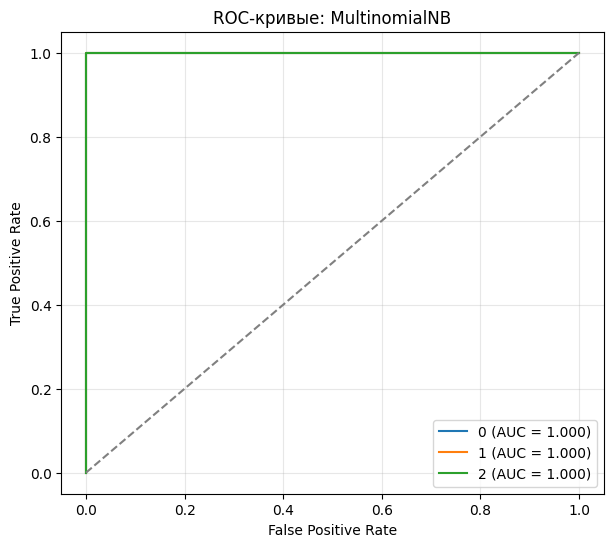

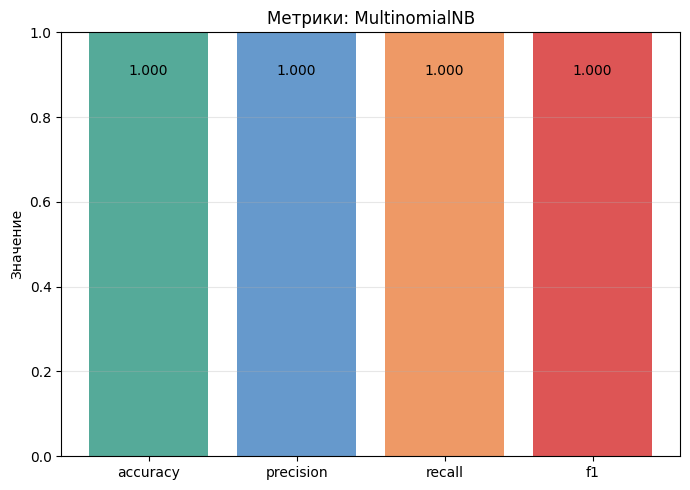

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(



=== BernoulliNB ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       0.52      1.00      0.68        92
      coconut       1.00      1.00      1.00       100
custard apple       0.51      1.00      0.67       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00      1.00      1.0

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

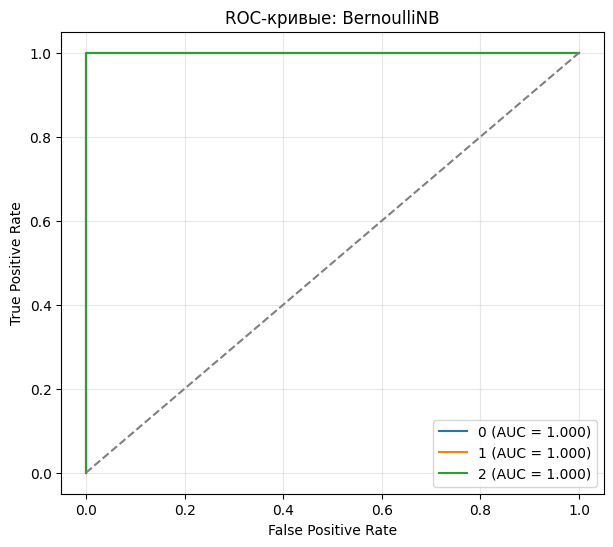

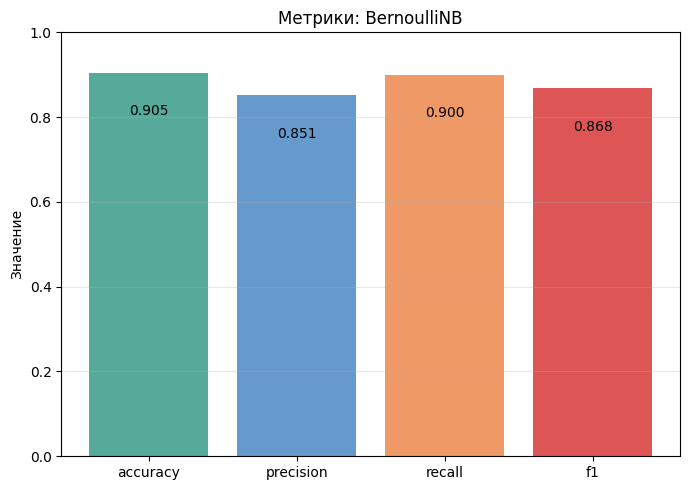

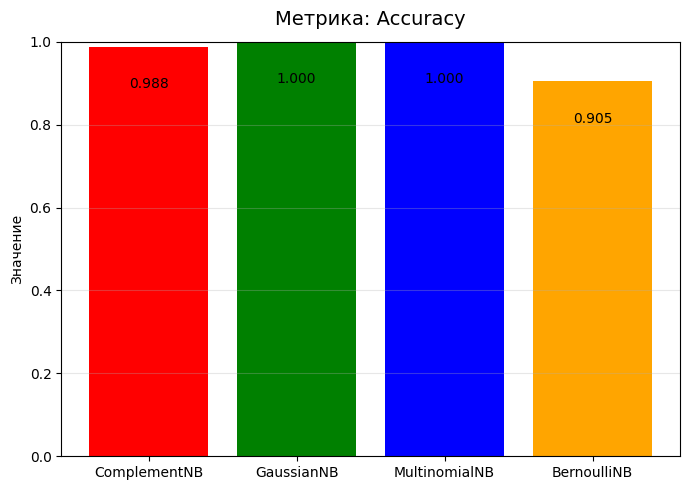

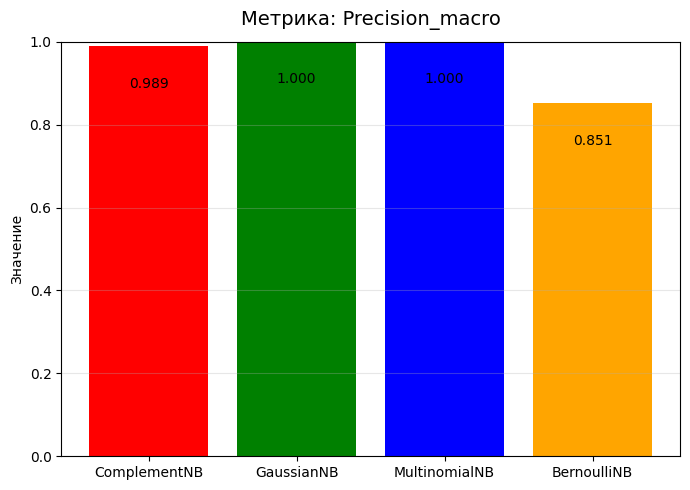

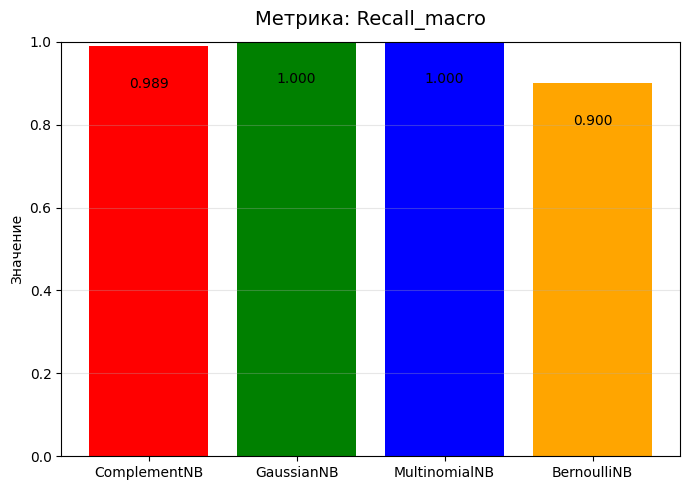

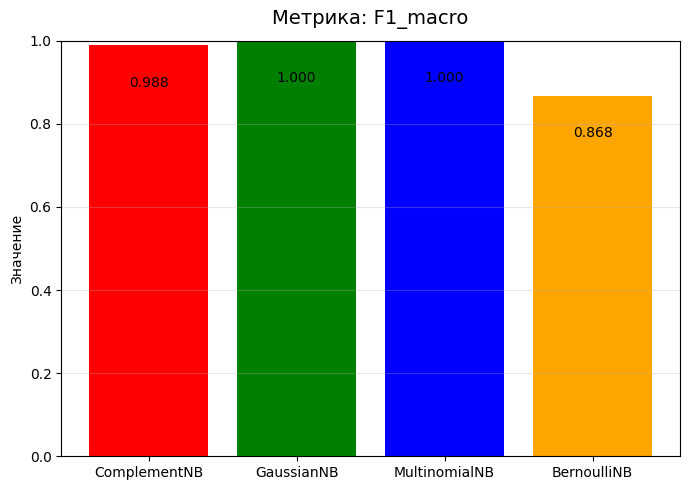

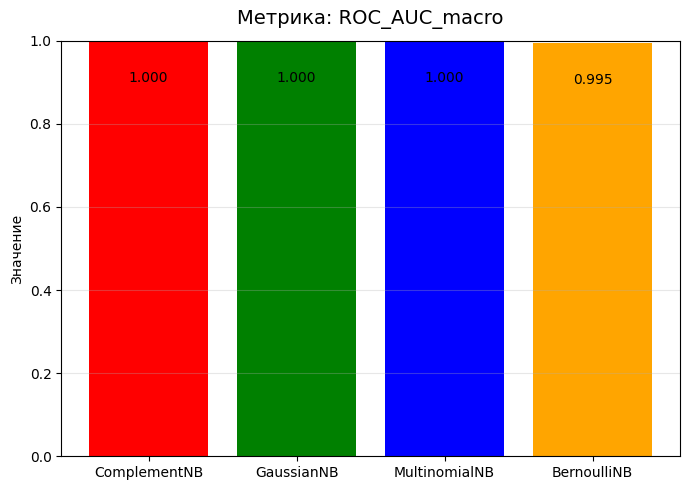

In [ ]:
# === Визуализация ===
def evaluate_and_plot(model_name, y_test, y_pred, y_proba=None, classes=None):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    

    if y_proba is not None and len(np.unique(y_test)) > 2:
        from sklearn.preprocessing import label_binarize

        y_bin = label_binarize(y_test, classes=classes)
        n_classes = y_bin.shape[1]
        max_curves = min(3, n_classes)

        auc_values = []
        roc_data = []

        for i in range(max_curves):
            try:
                auc_val = roc_auc_score(y_bin[:, i], y_proba[:, i])
            except ValueError:
                auc_val = np.nan

            auc_values.append(auc_val)

            if not np.isnan(auc_val):
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
                roc_data.append((i, fpr, tpr, auc_val))

        if len(roc_data) == 0:
            print(f"[INFO] ROC недоступен для {model_name}: все AUC = NaN")
        else:
            plt.figure(figsize=(7, 6))

            for (i, fpr, tpr, auc_val) in roc_data:
                plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc_val:.3f})')

            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC-кривые: {model_name}')
            plt.legend(loc='lower right')
            plt.grid(True, alpha=0.3)
            plt.show()


    metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    plt.figure(figsize=(7, 5))
    bars = plt.bar(list(metrics.keys()), list(metrics.values()),
                   color=['#5A9', '#69C', '#E96', '#D55'])
    plt.ylim(0, 1)
    plt.title(f'Метрики: {model_name}')
    plt.ylabel('Значение')
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.1, f"{height:.3f}", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return metrics

X = df[num_cols + cat_cols].copy()
y = df[target_col].astype(str)
results = {}


metrics_table = {
    'Model': [], 'Accuracy': [], 'Precision_macro': [],
    'Recall_macro': [], 'F1_macro': [],
    'ROC_AUC_macro': []
}

def add_metrics(name, yt, yp, y_proba=None, classes=None):
    metrics_table['Model'].append(name)
    metrics_table['Accuracy'].append(accuracy_score(yt, yp))
    metrics_table['Precision_macro'].append(precision_score(yt, yp, average='macro', zero_division=0))
    metrics_table['Recall_macro'].append(recall_score(yt, yp, average='macro', zero_division=0))
    metrics_table['F1_macro'].append(f1_score(yt, yp, average='macro', zero_division=0))

    if y_proba is not None and classes is not None:
        y_true_bin = label_binarize(yt, classes=classes)
        auc_macro = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    else:
        auc_macro = np.nan

    metrics_table['ROC_AUC_macro'].append(auc_macro)




le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print(f"Найдено классов: {len(class_names)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('kbins', KBinsDiscretizer(n_bins=6, encode='onehot-dense', strategy='quantile'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


# ================================================================
# ===  ComplementNB ===
# ================================================================

model_cnb = Pipeline([
    ('preprocess', preprocessor),
    ('clf', ComplementNB())
])

model_cnb.fit(X_train, y_train)
pred_cnb = model_cnb.predict(X_test)
proba_cnb = model_cnb.predict_proba(X_test)

print("\n=== ComplementNB ===")
print(classification_report(y_test, pred_cnb, target_names=class_names))

metrics_cnb = evaluate_and_plot("ComplementNB", y_test, pred_cnb, proba_cnb, classes=np.arange(len(class_names)))



# ================================================================
# ===  GaussianNB  ===
# ================================================================

gauss_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

gauss_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_gauss = ColumnTransformer([
    ('num', gauss_num, num_cols),
    ('cat', gauss_cat, cat_cols)
])

model_gnb = Pipeline([
    ('prep', preprocessor_gauss),
    ('clf', GaussianNB())
])

model_gnb.fit(X_train, y_train)
pred_gnb = model_gnb.predict(X_test)
proba_gnb = model_gnb.predict_proba(X_test)

print("\n=== GaussianNB ===")
print(classification_report(y_test, pred_gnb, target_names=class_names))

metrics_gnb = evaluate_and_plot("GaussianNB", y_test, pred_gnb, proba_gnb, classes=np.arange(len(class_names)))



# ================================================================
# ===  MultinomialNB ===
# ================================================================

model_mnb = Pipeline([
    ('preprocess', preprocessor),
    ('clf', MultinomialNB())
])

model_mnb.fit(X_train, y_train)
pred_mnb = model_mnb.predict(X_test)
proba_mnb = model_mnb.predict_proba(X_test)

print("\n=== MultinomialNB ===")
print(classification_report(y_test, pred_mnb, target_names=class_names))

metrics_mnb = evaluate_and_plot("MultinomialNB", y_test, pred_mnb, proba_mnb, classes=np.arange(len(class_names)))



# ================================================================
# ===  BernoulliNB ===
# ================================================================

bern_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('bin', KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile'))
])

bern_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_bern = ColumnTransformer([
    ('num', bern_num, num_cols),
    ('cat', bern_cat, cat_cols)
])

model_bnb = Pipeline([
    ('prep', preprocessor_bern),
    ('clf', BernoulliNB())
])

model_bnb.fit(X_train, y_train)
pred_bnb = model_bnb.predict(X_test)
proba_bnb = model_bnb.predict_proba(X_test)

print("\n=== BernoulliNB ===")
print(classification_report(y_test, pred_bnb, target_names=class_names))

metrics_bnb = evaluate_and_plot("BernoulliNB", y_test, pred_bnb, proba_bnb, classes=np.arange(len(class_names)))


add_metrics("ComplementNB", y_test, pred_cnb, proba_cnb, classes=np.arange(len(class_names)))
add_metrics("GaussianNB",   y_test, pred_gnb, proba_gnb, classes=np.arange(len(class_names)))
add_metrics("MultinomialNB", y_test, pred_mnb, proba_mnb, classes=np.arange(len(class_names)))
add_metrics("BernoulliNB", y_test, pred_bnb, proba_bnb, classes=np.arange(len(class_names)))

# ================================================================
# === Итог ===
# ================================================================

metrics_df = pd.DataFrame(metrics_table)


model_colors = {
    "ComplementNB": "red",
    "GaussianNB": "green",
    "MultinomialNB": "blue",
    "BernoulliNB": "orange"
}

models = metrics_df["Model"].tolist()

metric_names = [
    "Accuracy",
    "Precision_macro",
    "Recall_macro",
    "F1_macro",
    "ROC_AUC_macro"
]

for metric in metric_names:
    plt.close()        
    plt.figure(figsize=(7, 5))

    values = metrics_df[metric].values
    colors = [model_colors[m] for m in models]

    plt.bar(models, values, color=colors)

    plt.title(f"Метрика: {metric}", fontsize=14, pad=12)
    plt.ylabel("Значение")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    for i, v in enumerate(values):
        plt.text(i, v - 0.1, f"{v:.3f}", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

Выше представлены результаты работы четырёх вариаций наивных байесовских классификаторов: ComplementNB, GaussianNB, MultinomialNB и BernoulliNB. Каждый из этих алгоритмов основан на собственных предположениях о природе входных данных, поэтому для корректной работы требует различной подготовки признаков. ComplementNB и MultinomialNB ориентированы на дискретные частоты признаков. Категориальные признаки в этих моделях кодируются при помощи OneHotEncoder, преобразующего каждую категорию в отдельный бинарный столбец; таким образом, признаки становятся дискретными и совместимыми с мультиномиальной формулировкой алгоритмов. Числовые признаки в этих моделях дискретизируются с помощью KBinsDiscretizer, который разбивает диапазон значений на интервалы и заменяет каждое исходное значение номером интервала, что позволяет превратить непрерывные данные в условно-дискретные признаки.

GaussianNB. Подготовка данных для него минимальна: достаточно обработать пропущенные значения, например медианой, после чего признаки могут быть поданы модели в исходном числовом виде. Категориальные признаки в этом случае могут быть преобразованы в числовую форму с помощью OneHotEncoder.

BernoulliNB основан на предположении о бинарной природе признаков и интерпретирует каждый признак как логическое событие (да/нет). Поэтому категориальные признаки также удобно кодировать с помощью OneHotEncoder, который естественным образом даёт бинарные индикаторы. Числовые признаки для BernoulliNB необходимо преобразовать в бинарную форму,перевести непрерывные значения в формат “0/1”.

Теперь оценим полученные метрики.

Исходя из графиков, очевидно, что хуже всего справился BernoulliNB. Каждая его метрика имеет наименьшее значение, но даже при этом, значения высокие: accuracy 0.905, precision 0.851, recall 0.9, f1-score 0.868, roc-auc 0.995. 

У остальных методов все метрики крайне близки к 1. Скорее всего этого говорит о том, что данные достаточно легко классифицируются. Например, есть параметр "цвет" и он свойственен только для одного фрукта. Очевидно, что таких признаков у нас несколько. 


Вывод: Лучшие результаты показала модель GaussianNB, MultinomialNB.


Теперь рассмотрим как гиперпараметры каждого метода влияют на качество классификации.


=== ComplementNB_new ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       0.88      1.00      0.94       100
custard apple       0.90      1.00      0.95       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      0.88      0.94       107
         plum       1.00      1.00    

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


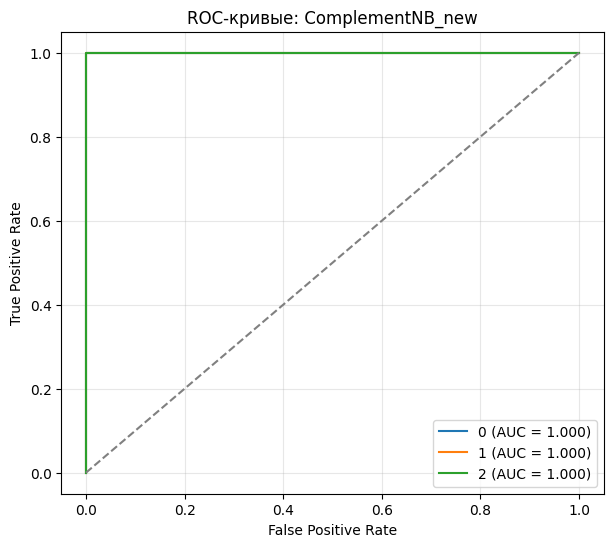

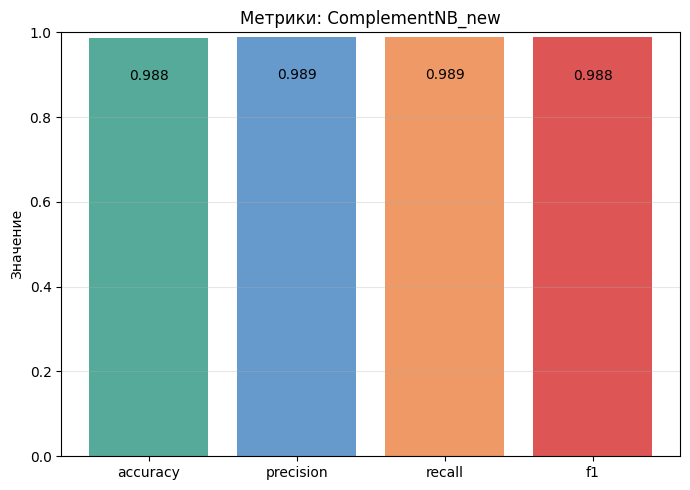

In [4]:
# ================================================================
# ===  ComplementNB NEW ===
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

model_cnb_new = Pipeline([
    ('preprocess', preprocessor),
    ('clf', ComplementNB(
            alpha=7.0,
            force_alpha=True,
            fit_prior=False,
            class_prior=None,
            norm=False
        ) )
])

model_cnb_new.fit(X_train, y_train)
pred_cnb_new = model_cnb_new.predict(X_test)
proba_cnb_new = model_cnb_new.predict_proba(X_test)



print("\n=== ComplementNB_new ===")
print(classification_report(y_test, pred_cnb_new, target_names=class_names))

metrics_cnb_new = evaluate_and_plot("ComplementNB_new", y_test, pred_cnb_new, proba_cnb_new, classes=np.arange(len(class_names)))



Здесь мы изменили параметры: alpha=7.0 (было значение 1.0), fit_prior=False (по умолчанию True). Параметр alpha отвечает за сглаживание Лапласа, fit_prior отвечает за оценку априорных вероятностей классов.

Исходя из метрик, изменение параметров не дало никакого результата. Наверное, дефолтные параметры уже дали максимально возможные значения метрик. Текущие параметры модели стоит считать избыточными для текущего датасета.


=== GaussianNB NEW ===
               precision    recall  f1-score   support

        apple       0.96      1.00      0.98        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       0.82      0.76      0.79       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       0.96      0.89      0.92        96
         kiwi       1.00      1.00      1.00       101
       lychee       0.94      1.00      0.97        99
        mango       1.00      0.53      0.69       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       0.90      0.93      0.91       107
    pineapple       0.79      0.84      0.81       107
         plum       1.00      1.00      

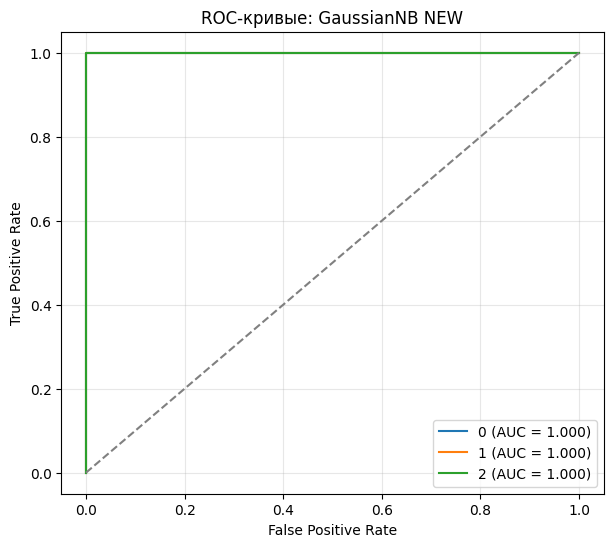

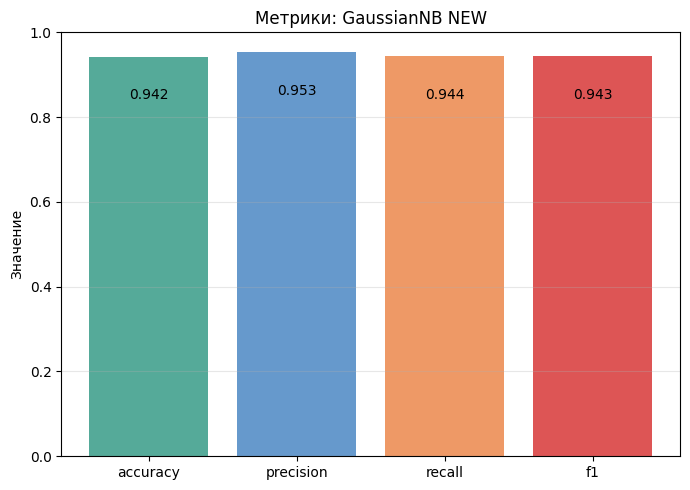

In [5]:
# ================================================================
# ===  GaussianNB NEW  ===
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

model_gnb_new = Pipeline([
    ('prep', preprocessor_gauss),
    ('clf', GaussianNB(
    priors=None,
    var_smoothing=1e-4
))
])

model_gnb_new.fit(X_train, y_train)
pred_gnb_new = model_gnb_new.predict(X_test)
proba_gnb_new = model_gnb_new.predict_proba(X_test)

print("\n=== GaussianNB NEW ===")
print(classification_report(y_test, pred_gnb_new, target_names=class_names))

metrics_gnb_new = evaluate_and_plot("GaussianNB NEW", y_test, pred_gnb_new, proba_gnb_new, classes=np.arange(len(class_names)))

В этой модели мы изменили параметр var_smoothing. Он добавляет малое значение к дисперсии, чтобы сделать модель более устойчивой. 

Дефолтное значение этого параметра 1e-9. В модели показанной выше мы изменили это значение до 1e-4. 

По метрикам мы видим, что значения упали, по сравнению с дефолтными. Но тем не менее, показатели можно назвать хорошими, модель хорошо классифицирует данные,так как все новые метрики больше либо равны 0,933.


=== MultinomialNB NEW ===
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00      1.00   

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


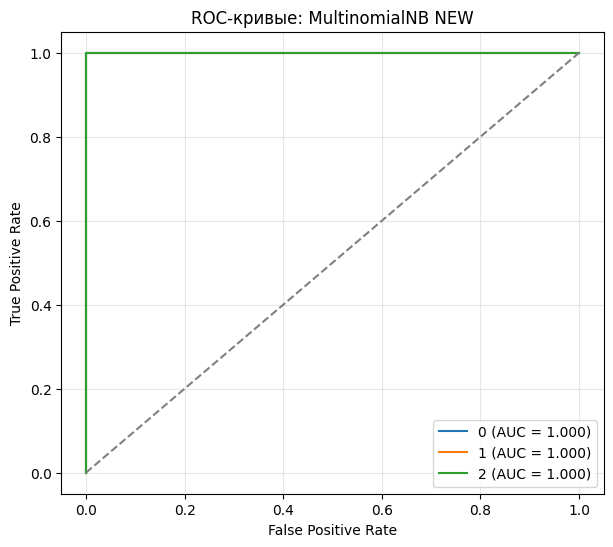

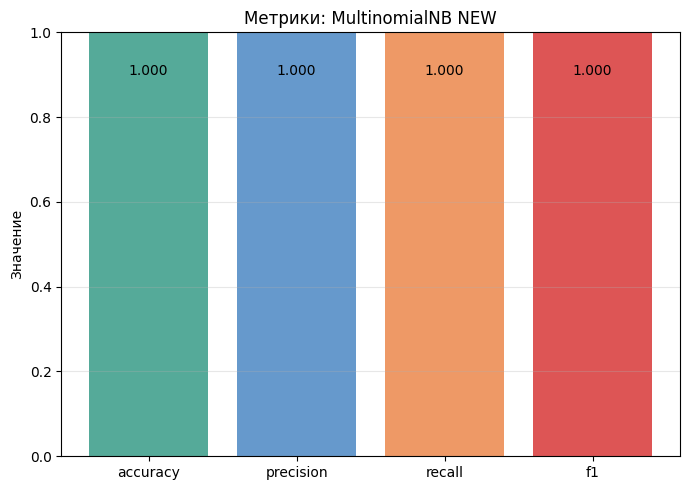

In [6]:
# ================================================================
# === MultinomialNB NEW ===
# ================================================================

model_mnb_new = Pipeline([
    ('preprocess', preprocessor),
    ('clf', MultinomialNB(
    alpha=4.0,
    fit_prior=False,
    class_prior=None
))
])

model_mnb_new.fit(X_train, y_train)
pred_mnb_new = model_mnb_new.predict(X_test)
proba_mnb_new = model_mnb_new.predict_proba(X_test)

print("\n=== MultinomialNB NEW ===")
print(classification_report(y_test, pred_mnb_new, target_names=class_names))

metrics_mnb_new = evaluate_and_plot("MultinomialNB NEW", y_test, pred_mnb_new, proba_mnb_new, classes=np.arange(len(class_names)))


Здесь мы изменили параметры alpha=4.0,fit_prior=False. Их дефолтные значения равны 1.0 и True соответственно. Параметр alpha отвечает за сглаживание Лапласа, fit_prior отвечает за оценку априорных вероятностей классов. Указав значение false мы фактически указали, что все классы встречаются равновероятно.

Полученные метрики говорят о том, что нас классификатор отлично справляется с распознанием фруктов, хотя значения метрик и упало по сравнению с дефолтными параметрами (0,005), новая модель тоже работает отлично.


=== BernoulliNB NEW ===
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       0.52      1.00      0.68        92
      coconut       1.00      1.00      1.00       100
custard apple       0.51      1.00      0.67       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       0.00      0.00      0.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       0.51      1.00      0.68       107
         plum       1.00      1.00     

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

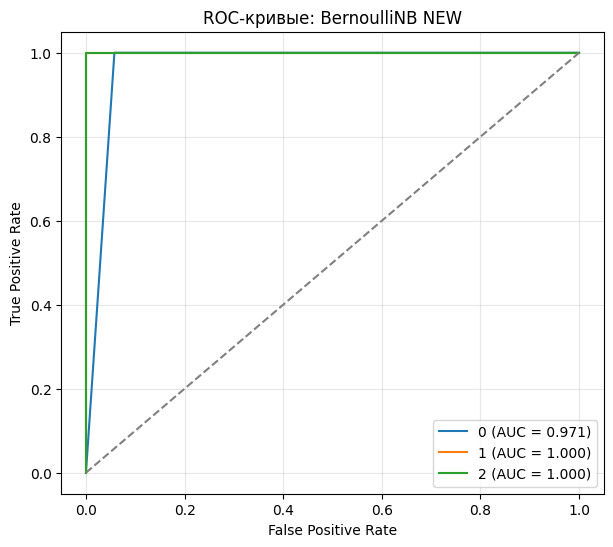

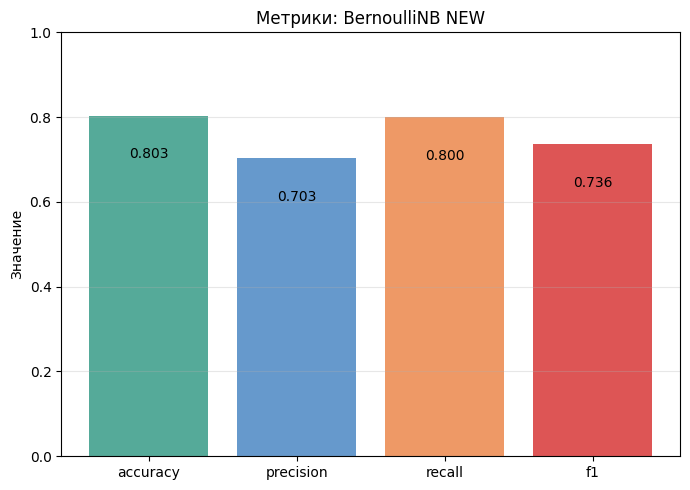

In [ ]:
# ================================================================
# ===  BernoulliNB NEW ===
# ================================================================

preprocessor_bern_new = ColumnTransformer([
    ('cat', bern_cat, cat_cols)
])

model_bnb_new = Pipeline([
    ('prep', preprocessor_bern_new),
    ('clf', BernoulliNB(
    alpha=4.0,
    binarize=0.5,
    fit_prior=True,
    class_prior=None
))
])

model_bnb_new.fit(X_train, y_train)
pred_bnb_new = model_bnb_new.predict(X_test)
proba_bnb_new = model_bnb_new.predict_proba(X_test)

print("\n=== BernoulliNB NEW ===")
print(classification_report(y_test, pred_bnb_new, target_names=class_names))

metrics_bnb_new = evaluate_and_plot("BernoulliNB NEW", y_test, pred_bnb_new, proba_bnb_new, classes=np.arange(len(class_names)))

Здесь мы поменяли параметры  alpha=4.0,binarize=0.5. Их дефолтные значения равны 1.0 и 0.0 соответственно. Первый параметр, как и в других описанных выше методах отвечает за сглаживание, второй параметр фактически определяет способ бинаризации данных.

Полчуенные метрики для новой модели хуже, чем полученные метрики с дефолтными значениями параметров. Исходные метрики: accuracy 0.906; precision 0.851;recall 0.9; f1-score 0.868.
Как видим, с новыми параметрами качество классификатора упало примерно на 0.1 по всем метрикам.

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

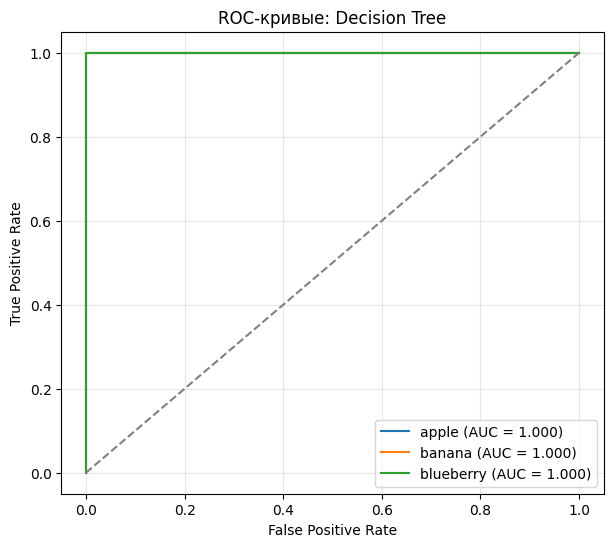

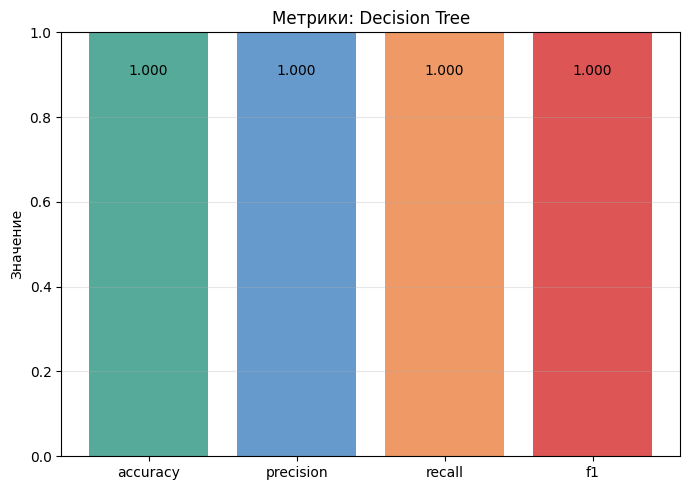

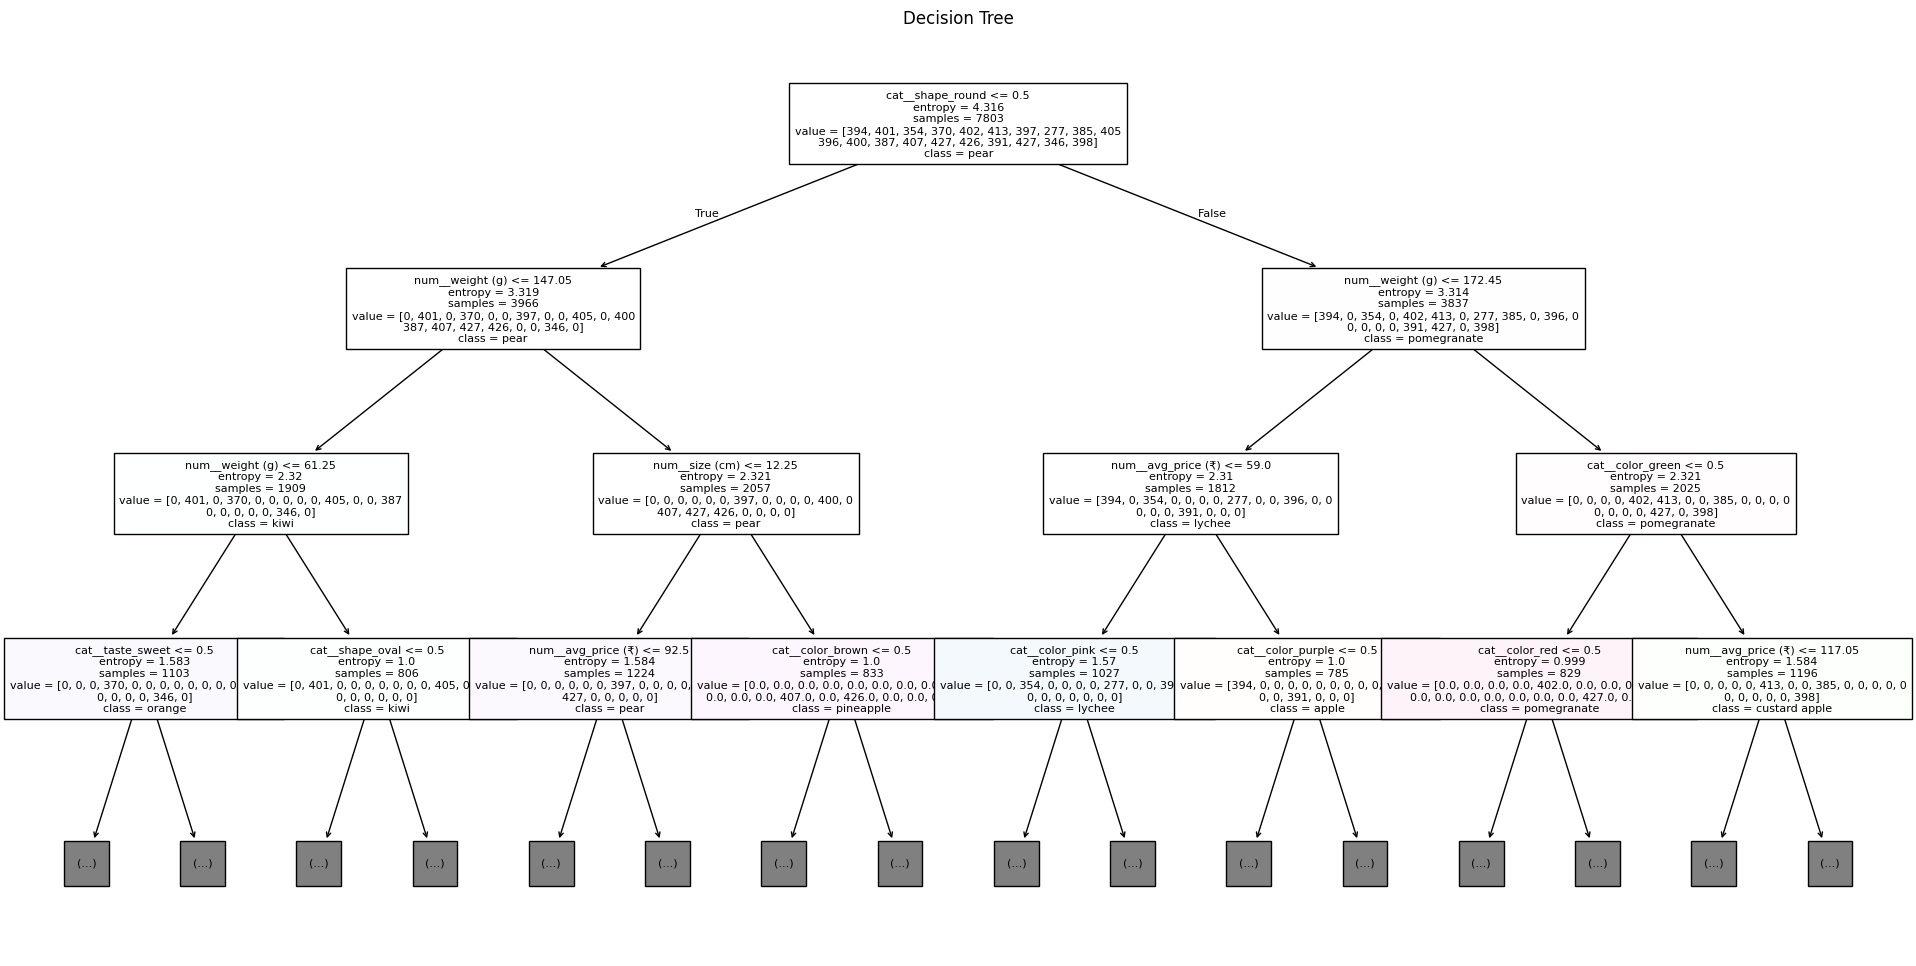

In [ ]:
# ================================================================
# ===  Decision Tree ===
# ================================================================

X = df.drop(columns=['fruit_name'])
y = df['fruit_name']


num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']


num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='entropy',  
        max_depth=6,          
        random_state=42
    ))
])


tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test) 

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


metrics_dt = evaluate_and_plot(
    model_name="Decision Tree",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    classes=tree_model.named_steps['classifier'].classes_
)
add_metrics("DT", y_test, y_pred, y_proba, classes=tree_model.named_steps['classifier'].classes_)

clf = tree_model.named_steps['classifier']
X_proc = preprocessor.fit_transform(X_train)

plt.figure(figsize=(24, 12))
plot_tree(clf, feature_names=preprocessor.get_feature_names_out(),
          class_names=clf.classes_, filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree")
plt.show()

Выше представлены результаты работы модели Дерева решений (Decision Tree). Дерево решений является алгоритмом, который рекурсивно разделяет пространство признаков на подпространства, выбирая оптимальные разбиения по каждому признаку для максимизации чистоты классов в листьях. Для работы дерева подготовки данных требуется минимальная: числовые признаки без изменений, а категориальные признаки были закодированы через OneHotEncoder, что позволило дереву корректно работать с категориальными признаками.

Исходя из полученных метрик, дерево решений показало идеальные результаты на тестовой выборке: все метрики равны 1. 



Как уже упоминалось выше,такой результат указывает на то, что комбинация признаков в датасете обеспечивает очень хорошее разделение классов, и модель полностью корректно классифицирует объекты на тестовой выборке. Вероятно, это связано с наличием признаков, уникальных для конкретных фруктов, таких как цвет, форма или размер, что позволяет дереву безошибочно разделять все классы. 

Также можно предположить, что текущее ограничение на глубину дерева (6) избыточно. Это мы проверим при изучении влияния гиперпараметров модели

Accuracy: 0.8749359302921579

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       0.00      0.00      0.00        89
       cherry       0.27      1.00      0.43        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       0.00      0.00      0.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         p

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

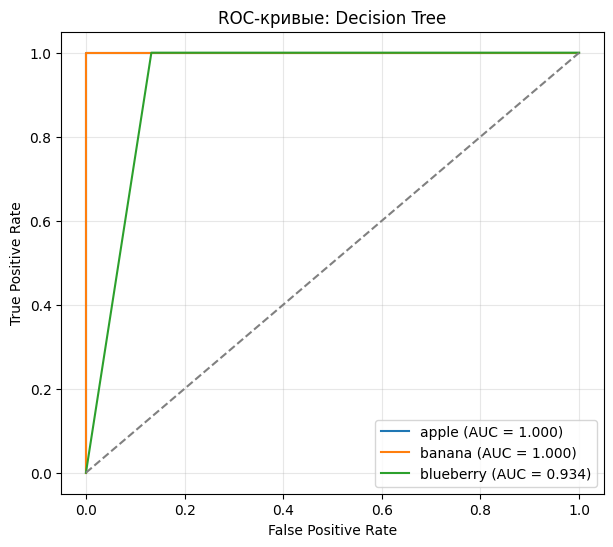

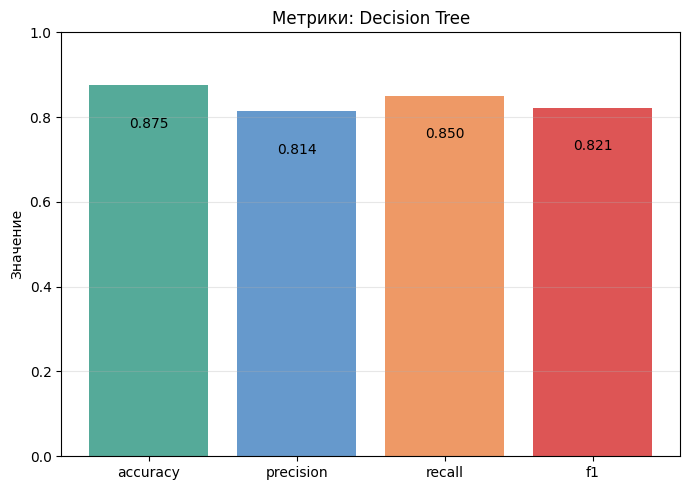

In [ ]:
# ================================================================
# ===  Decision Tree New ===
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


tree_model_new = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',  
        max_depth=10,          
        random_state=42
    ))
])


tree_model_new.fit(X_train, y_train)
y_pred_new = tree_model_new.predict(X_test)
y_proba_new = tree_model_new.predict_proba(X_test) 

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new))


metrics_dt = evaluate_and_plot(
    model_name="Decision Tree",
    y_test=y_test,
    y_pred=y_pred_new,
    y_proba=y_proba_new,
    classes=tree_model_new.named_steps['classifier'].classes_
)

В модели дерева решений мы вновь изменили 2 параметра: criterion='gini',  max_depth=10. Изначально мы использовали критерий  criterion='entropy', max_depth=6.

Исходя из полученных метрик, а также таблицы приведенной выше, мы видим, что модель с критерием 'gini' и глубиной 10 кратно хуже подходит для нашего датасета, ведь некоторые классы даже не были предсказаны. Изначально все наши метрики были равны 1, сейчас же не превышают 0,91. Очевидно, что даже большая глубина не смогла "исправить ситуацию". Это показывает нам, какой вклад в качество классификатора вносит выбранный критерий.

Accuracy: 0.9928241927216812

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       0.98      0.97      0.97       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       0.96      0.96      0.96        96
         kiwi       1.00      1.00      1.00       101
       lychee       0.99      1.00      0.99        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       0.96      0.96      0.96       107
    pineapple       0.97      0.98      0.98       107
         p

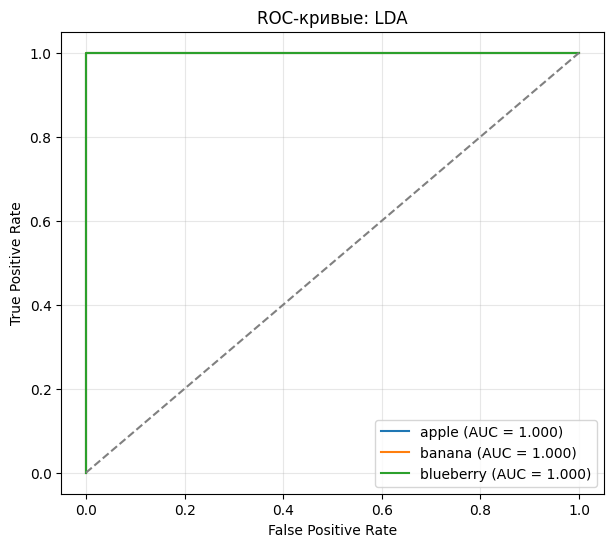

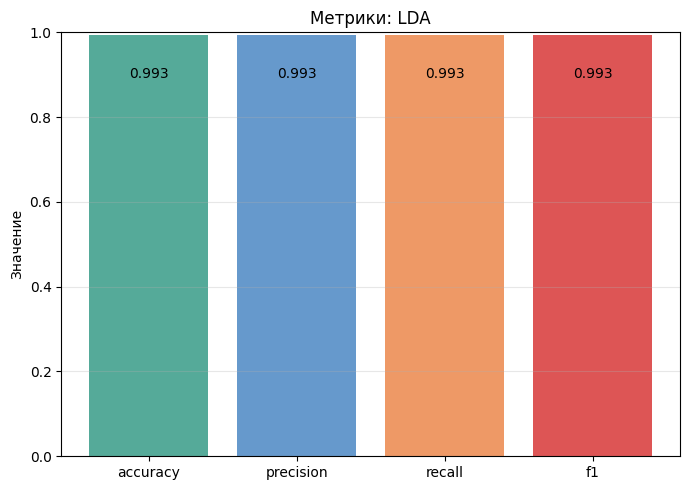

In [10]:
# ================================================================
# ===  LDA ===
# ================================================================

X = df.drop(columns=['fruit_name'])
y = df['fruit_name']


num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


lda_model = Pipeline([
    ('preprocessor', preprocessor),
    ('lda', LinearDiscriminantAnalysis())
])


lda_model.fit(X_train, y_train)
y_pred = lda_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
y_proba = lda_model.predict_proba(X_test)


metrics_lda = evaluate_and_plot(
    model_name="LDA",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    classes=lda_model.named_steps['lda'].classes_
)
add_metrics("LDA", y_test, y_pred, y_proba=y_proba, classes=lda_model.named_steps['lda'].classes_)

Выше представлены результаты работы модели Линейного дискриминантного анализа. LDA является алгоритмом, который ищет линейные комбинации признаков, максимизирующие разделение между классами, проецируя данные в новое пространство, где классы наиболее разнесены. Этот алгоритм чувствителен для к входным данным,поэтому требуется корректная подготовка данных: числовые признаки были стандартизированы с помощью StandardScaler для нормализации масштабов, а категориальные признаки закодированы через OneHotEncoder.

Исходя из полученных метрик, LDA показала высокую эффективность на тестовой выборке: accuracy, precision, recall и f1-score составляют примерно 0.993.
Площадь под ROC кривой равна 1, что говорит о способности классификатора корректно различать все классы. 

Такой результат указывает на то, что выбранная комбинация признаков обеспечивает хорошее разделение классов.

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

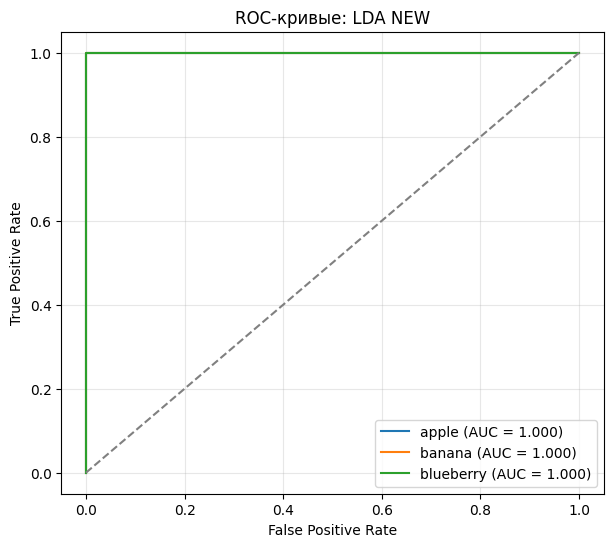

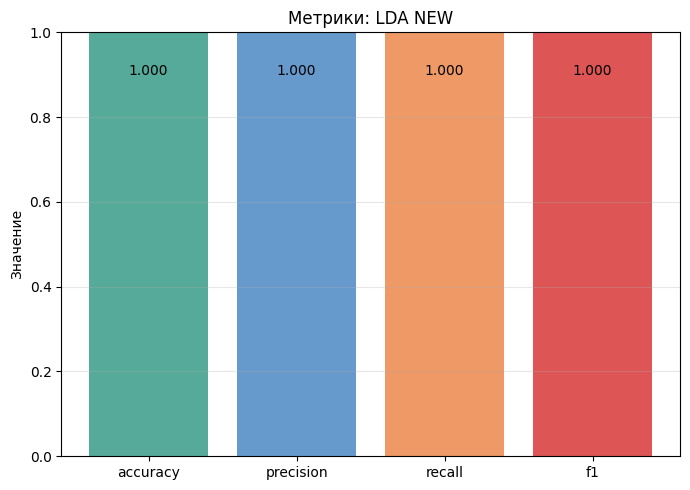

In [11]:
# ================================================================
# ===  LDA NEW ===
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


lda_model_new = Pipeline([
    ('preprocessor', preprocessor),
    ('lda', LinearDiscriminantAnalysis(solver='lsqr',      
        shrinkage='auto' ))
])


lda_model_new.fit(X_train, y_train)
y_pred_new = lda_model_new.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new))
y_proba_new = lda_model_new.predict_proba(X_test)


metrics_lda = evaluate_and_plot(
    model_name="LDA NEW",
    y_test=y_test,
    y_pred=y_pred_new,
    y_proba=y_proba_new,
    classes=lda_model_new.named_steps['lda'].classes_
)

В новой модели ЛДА мы изменили параметры: solver='lsqr', shrinkage='auto'.

Первый параметр отвечает за метод вычисления проекции ЛДА, второй отвечает за регуляризацию ковариационной матрицы. Дефолтые значения:solver='svd', другие параметры ему не требуются,так как они применимы для других объектов solver.

Полученные метрики не уступают в своем качестве исходным: все значения равны 1. Это говорит о том, что ЛДА отлично подходит для выбранных данных. Несколько разных методов ЛДА показали максимально возможные метрики, это может говорить о линейной разделимости данных.

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

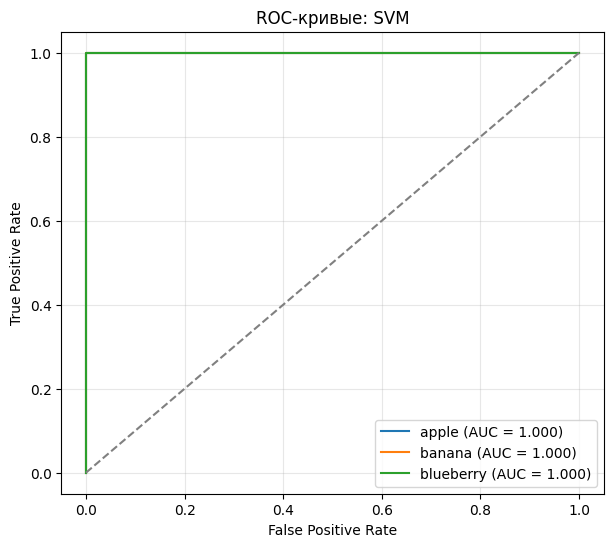

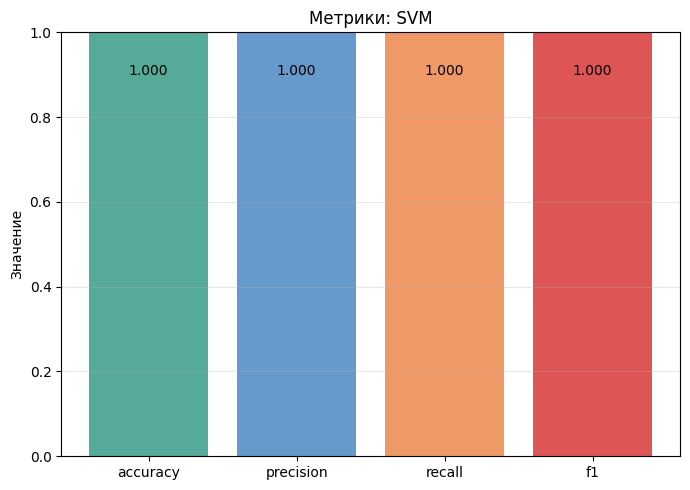

In [12]:
# ================================================================
# ===  SVM ===
# ================================================================

X = df.drop(columns=['fruit_name'])
y = df['fruit_name']


num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']


num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_svm = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


svm_model = Pipeline([
    ('preprocessor', preprocessor_svm),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale',probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_proba = svm_model.predict_proba(X_test)


metrics_svm = evaluate_and_plot(
    model_name="SVM",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    classes=svm_model.named_steps['svc'].classes_
)
add_metrics("SVM", y_test, y_pred, y_proba, classes=svm_model.named_steps['svc'].classes_)


Выше представлены результаты работы модели опорных векторов. Метод SVM ищет оптимальную разделяющую гиперплоскость, максимизирующую отступ между классами.

Для корректной работы модели числовые признаки были стандартизированы с помощью StandardScaler, поскольку масштаб признаков напрямую влияет на расстояния, используемые в функции. Категориальные признаки были преобразованы в бинарные с помощью OneHotEncoder.

Согласно полученным результатам, модель SVM показала идеальные значения всех метрик качества: accuracy, precision, recall и f1-score равны 1.0. Это означает, что классификатор безошибочно предсказал классы для всех объектов тестовой выборки.


Отдельно стоит отметить, что SVM  обычно хорошо работает в условиях нелинейных зависимостей, поэтому его способность достичь максимальных метрик подтверждает, что структура пространства признаков практически полностью разделима.

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

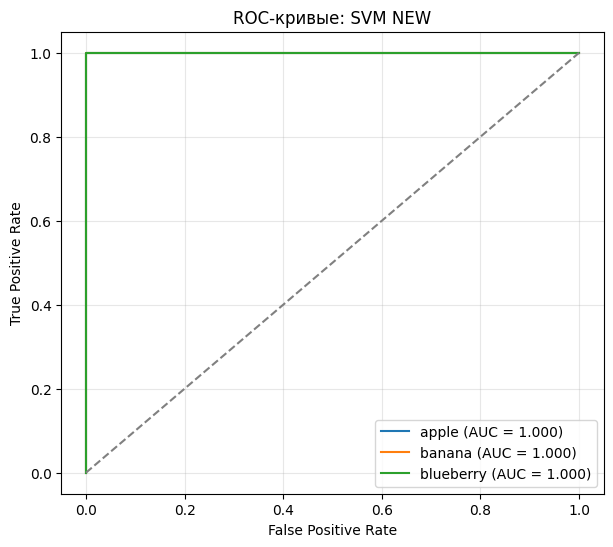

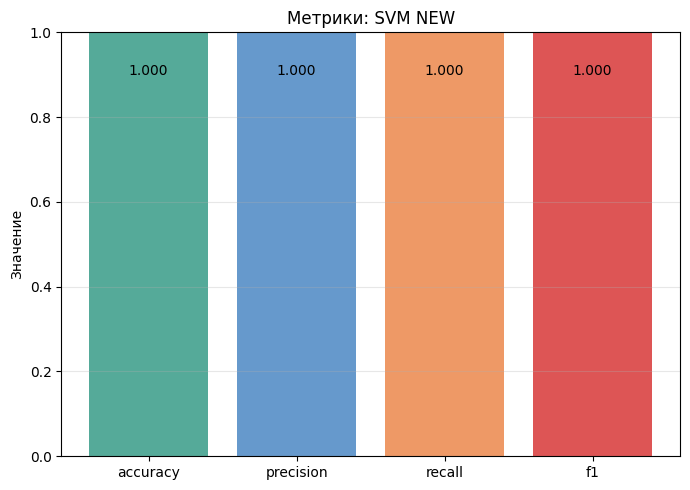

In [13]:
# ================================================================
# ===  SVM NEW ===
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


svm_model_new = Pipeline([
    ('preprocessor', preprocessor_svm),
    ('svc', SVC(kernel='poly',degree = 4,coef0 = 0.0, C=1.0,probability=True, random_state=42))
])

svm_model_new.fit(X_train, y_train)


y_pred_new = svm_model_new.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new))

y_proba_new = svm_model_new.predict_proba(X_test)


metrics_svm = evaluate_and_plot(
    model_name="SVM NEW",
    y_test=y_test,
    y_pred=y_pred_new,
    y_proba=y_proba_new,
    classes=svm_model_new.named_steps['svc'].classes_
)

При построении новой модели метода опорных векторов мы изменили модель координально.

Раньше использовали параметры: kernel='rbf', C=1.0, gamma='scale'; сейчас же выбрали такие: kernel='poly',degree = 4,coef0 = 0.0.

Теперь мы используем полиномиальное ядро, степень полинома выбрана 4, свободный член равен 0.

Однако, внесенные изменения никак не сказались на наших метриках. Они вновь все равны 1. Это подтверждает, что данные линейно разделимы.

Также стоит отметить важность предобработки данных. 

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

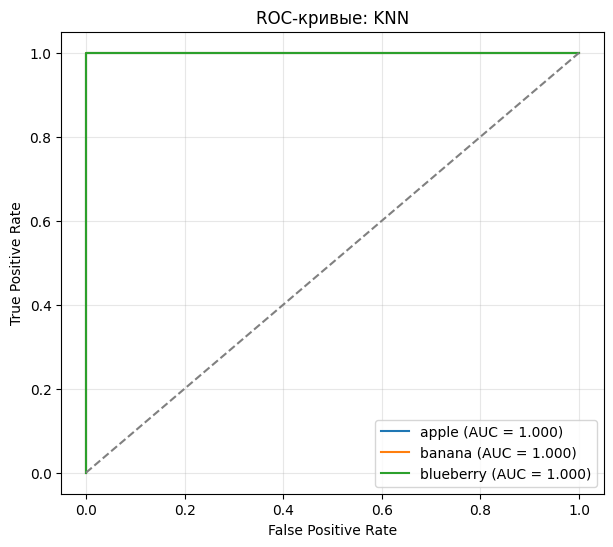

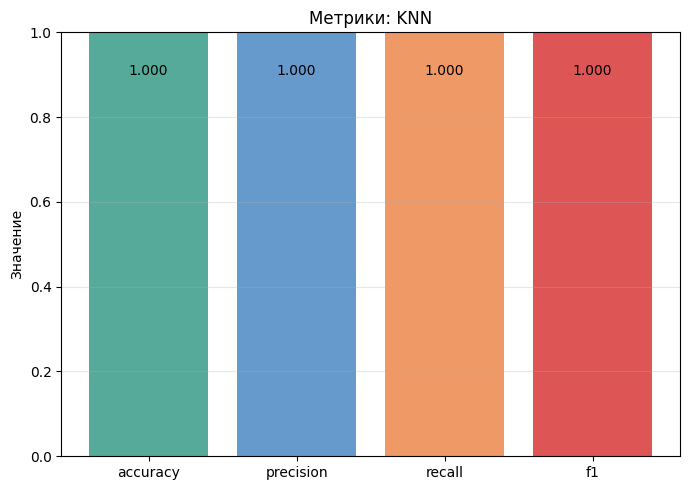

In [14]:
# ================================================================
# ===  KNN ===
# ================================================================

X = df.drop(columns=['fruit_name'])
y = df['fruit_name']


num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']


num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_knn = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


knn_model = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,       
        metric='minkowski',  
        p=2
    ))
])


knn_model.fit(X_train, y_train)


y_pred = knn_model.predict(X_test)
pred_knn = y_pred


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_proba = knn_model.predict_proba(X_test)


metrics_knn = evaluate_and_plot(
    model_name="KNN",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    classes=knn_model.named_steps['knn'].classes_
)
add_metrics("KNN", y_test, y_pred, y_proba=y_proba, classes=knn_model.named_steps['knn'].classes_)


Выше представлены результаты работы модели k ближайших соседей. 
В данной реализации использовано стандартное количество соседей (k = 5) и евклидова метрика расстояния.

Для корректной работы метода была выполнена обязательная стандартизация числовых признаков через StandardScaler, поскольку kNN чувствителен к масштабу данных: признаки с большим диапазоном значений начинают доминировать в расчёте расстояний. Категориальные признаки были преобразованы в бинарные индикаторы с помощью OneHotEncoder.

Согласно полученным метрикам, модель kNN показала идеальные результаты: accuracy, precision, recall и f1-score равны 1.0. Это означает, что классификатор безошибочно распознал все объекты тестовой выборки.

Подобный результат подтверждает, что структура данных обладает высокой степенью разделимости. Пространство признаков содержит параметры, которые однозначно идентифицируют класс фруктов, например уникальные сочетания формы, цвета, вкуса или размеров. Для таких данных метод ближайших соседей показывает себя особенно хорошо, поскольку решение напрямую основано на локальной похожести экземпляров.

Таким образом, kNN демонстрирует полное совпадение предсказаний с истинными значениями, что свидетельствует не только о выразительности признаков, но и о том, что в данном случае выбранный набор гиперпараметров достаточен.

Accuracy: 1.0

Classification Report:
                precision    recall  f1-score   support

        apple       1.00      1.00      1.00        98
       banana       1.00      1.00      1.00       101
    blueberry       1.00      1.00      1.00        89
       cherry       1.00      1.00      1.00        92
      coconut       1.00      1.00      1.00       100
custard apple       1.00      1.00      1.00       103
 dragon fruit       1.00      1.00      1.00        99
        grape       1.00      1.00      1.00        69
        guava       1.00      1.00      1.00        96
         kiwi       1.00      1.00      1.00       101
       lychee       1.00      1.00      1.00        99
        mango       1.00      1.00      1.00       100
       orange       1.00      1.00      1.00        97
       papaya       1.00      1.00      1.00       102
         pear       1.00      1.00      1.00       107
    pineapple       1.00      1.00      1.00       107
         plum       1.00 

c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\manui\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


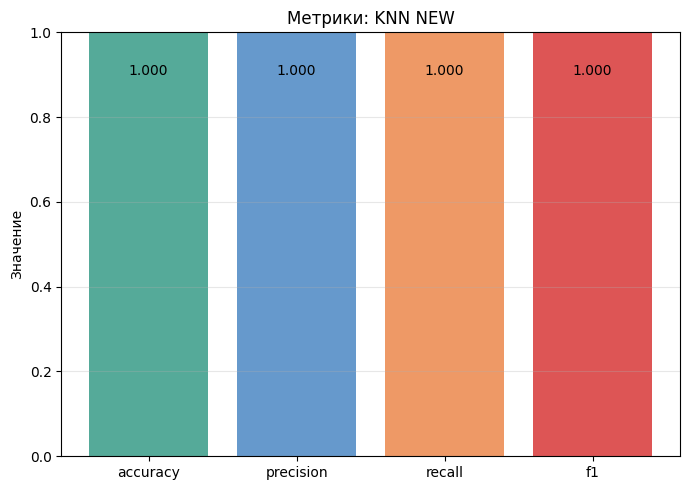

In [15]:
# ================================================================
# ===  KNN NEW ===
# ================================================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

knn_model_new = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('knn', KNeighborsClassifier(
        n_neighbors=2,
        metric='manhattan',
        weights='distance'
    ))
])

knn_model_new.fit(X_train, y_train)

y_pred_new = knn_model_new.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new, target_names=le.classes_))

y_proba_new = knn_model_new.predict_proba(X_test)
print(np.unique(y_proba_new, axis=0))


metrics_knn = evaluate_and_plot(
    model_name="KNN NEW",
    y_test=y_test,
    y_pred=y_pred_new,
    y_proba=y_proba_new,
    classes=le.classes_   
)


В исходной модели мы использовали параметры: n_neighbors=5, metric='minkowski', p=2. Количество соседий 5, расстояние ЕВклидово.

Тут мы взяли следующие параметры:  n_neighbors=2,metric='manhattan',weights='distance'. Количество соседий 2, Манхэттенское расстояние, а также способ вычисления весов соседий обратно пропорциональный расстоянию.

И вновь мы получили метрики равные 1 в обоих вариациях модели, что вновь наталкивает на мысль о том, что данные легко классифицируются любыми методами.

           Model  Accuracy  Precision_macro  Recall_macro  F1_macro  \
0   ComplementNB  0.987699         0.989423      0.988785  0.988471   
1     GaussianNB  1.000000         1.000000      1.000000  1.000000   
2  MultinomialNB  1.000000         1.000000      1.000000  1.000000   
3    BernoulliNB  0.904664         0.851212      0.900000  0.867734   
4             DT  1.000000         1.000000      1.000000  1.000000   
5            LDA  0.992824         0.993149      0.993032  0.993085   
6            SVM  1.000000         1.000000      1.000000  1.000000   
7            KNN  1.000000         1.000000      1.000000  1.000000   

   ROC_AUC_macro  
0       0.999957  
1       1.000000  
2       1.000000  
3       0.994920  
4       1.000000  
5       0.999964  
6       1.000000  
7       1.000000  


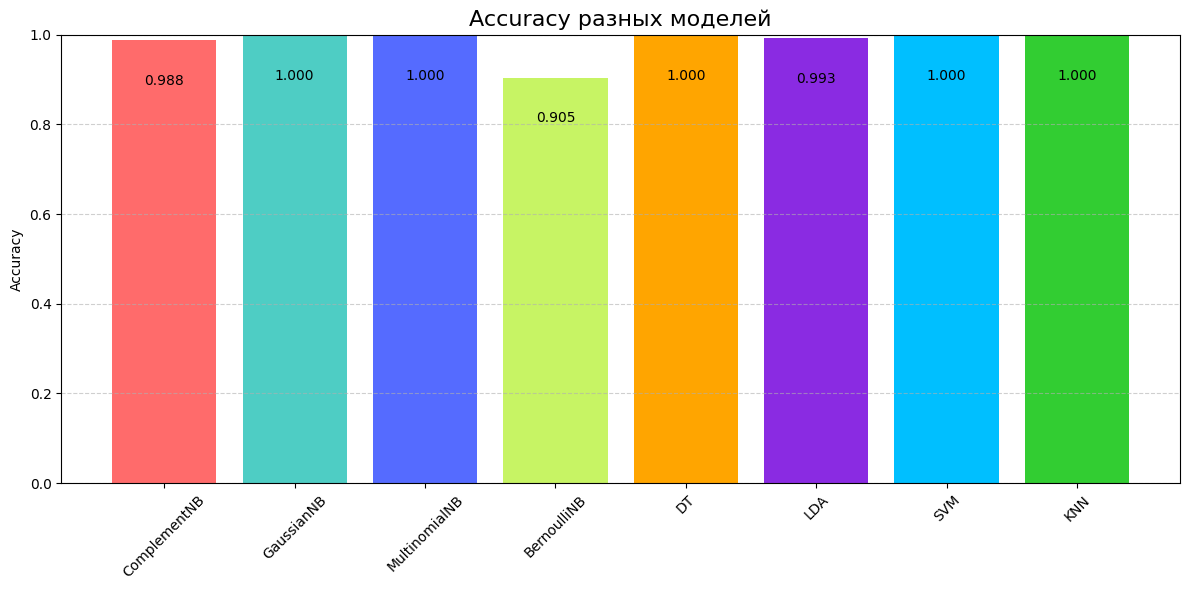

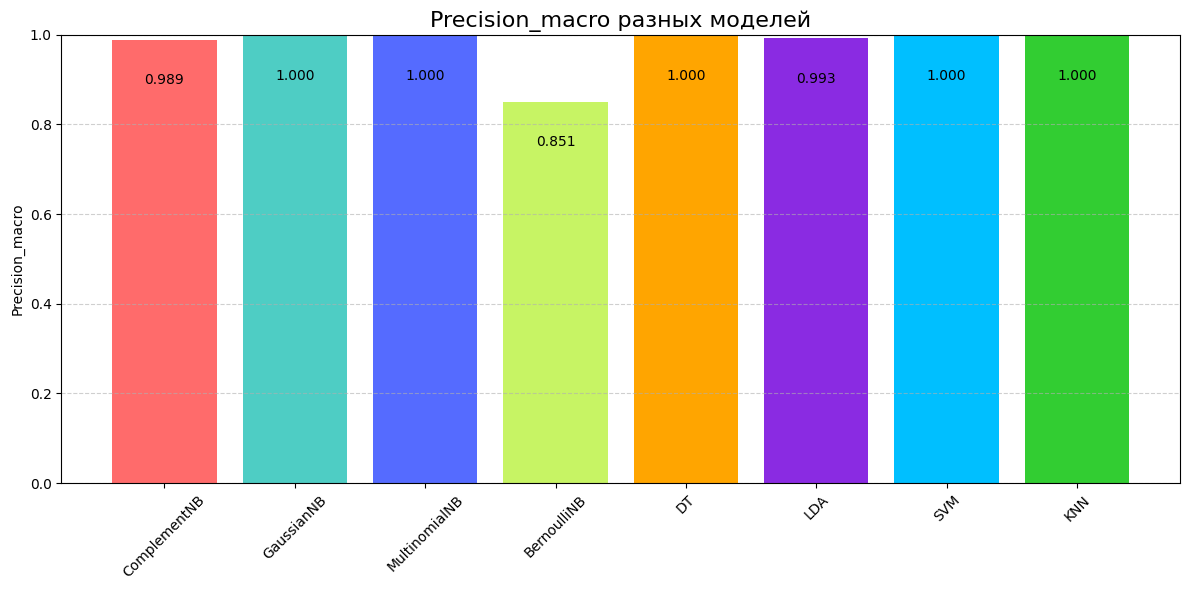

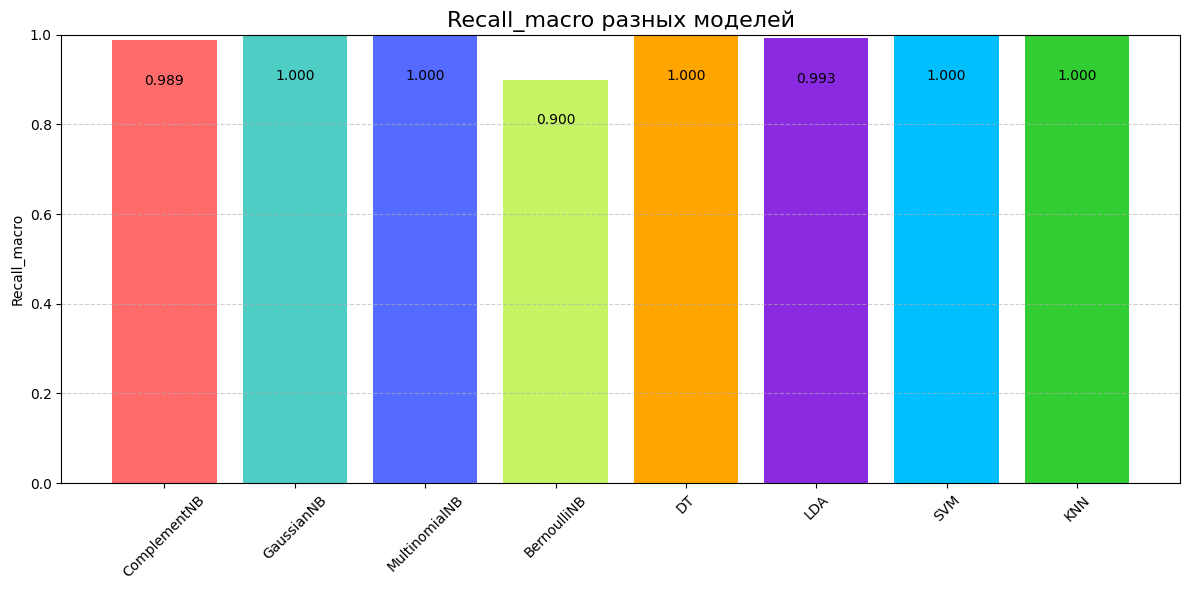

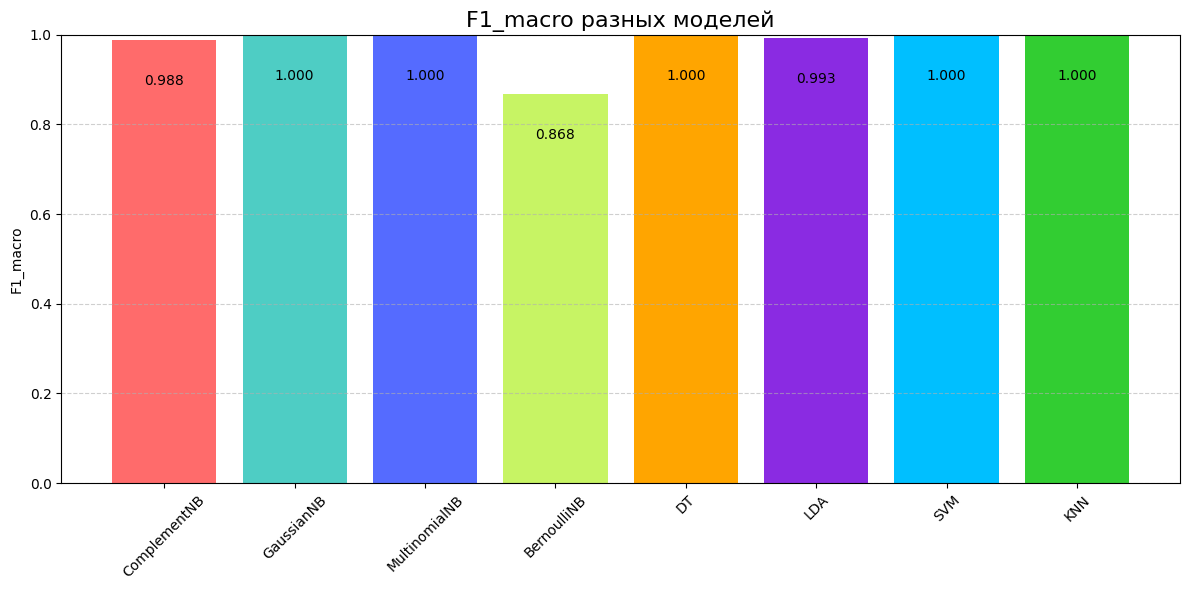

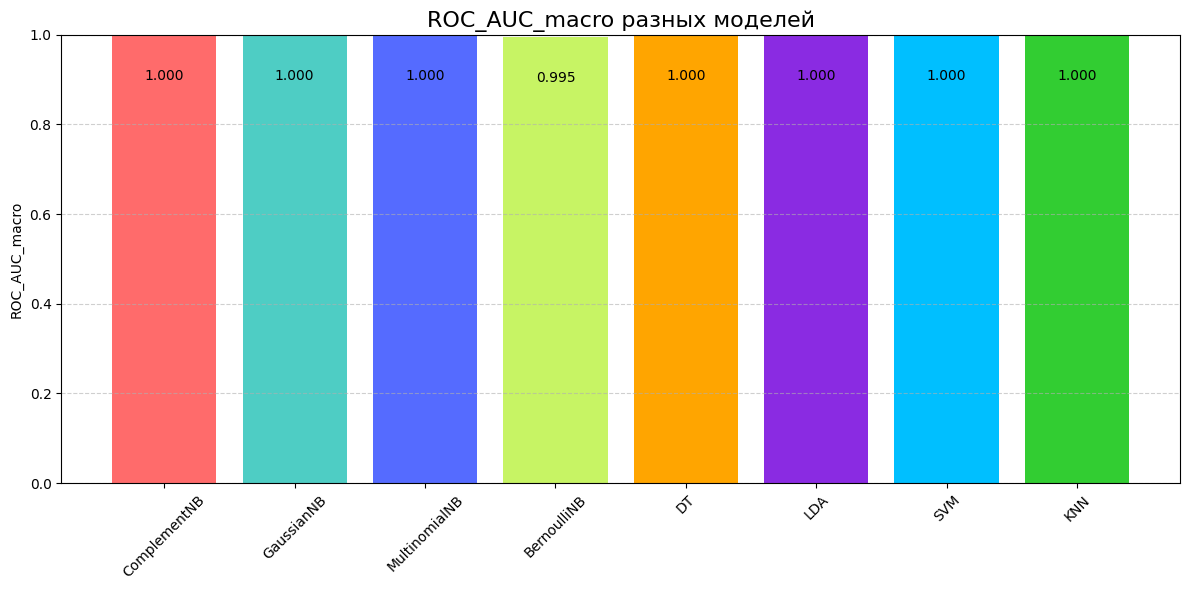

In [ ]:

compare_df = pd.DataFrame(metrics_table)
print(compare_df)

metrics = ["Accuracy","Precision_macro", "Recall_macro", "F1_macro", "ROC_AUC_macro"]

model_colors = {
    "ComplementNB": "#FF6B6B",
    "GaussianNB": "#4ECDC4",
    "MultinomialNB": "#556BFF",
    "BernoulliNB": "#C7F464",
    "DT": "#FFA500",
    "LDA": "#8A2BE2",
    "SVM": "#00BFFF",
    "KNN": "#32CD32"
}


for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.title(f"{metric} разных моделей", fontsize=16)
    models = compare_df["Model"]
    values = compare_df[metric]
    colors = [model_colors[m] for m in models]
    plt.bar(models, values, color=colors)
    for i, v in enumerate(values):
        plt.text(i, v - 0.1, f"{v:.3f}", ha='center', fontsize=10)

    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

Исходя из приведенных метрик, можно сделать вывод, что для наших данных подходят практически все реализованные модели.

GaussianNB, MultinomialNB, Decision Tree, SVM и KNN показали абсолютные значения по всем метрикам. Это говорит о том, что датасет хорошо структурирован, классы чётко разделимы, и модели не испытывают трудностей при классификации.

ComplementNB и LDA — почти идеальны Очень близки к 1.0. Их модели тоже можно считать адекватными, но оценивая метрики справились они чуть хуже.

BernoulliNB явный аутсайдер, так как существенно уступает остальным по всем метрикам. Вероятно, его предположения о бинарных признаках не соответствуют структуре данных.

In [ ]:
# ================================================================
# === MY ===
# ================================================================

base_logs = pathlib.Path(r"C:\tf_logs")  
base_logs.mkdir(parents=True, exist_ok=True)


stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
run_dir = base_logs / f"run_{stamp}"
run_dir.mkdir(parents=True, exist_ok=True)


tb_cb = keras.callbacks.TensorBoard(log_dir=str(run_dir), histogram_freq=1)
es_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

print("TensorBoard логи:", run_dir)

le = LabelEncoder()
y_enc = le.fit_transform(y)        
y_processed = to_categorical(y_enc)

num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']
cat_cols = ['shape', 'color', 'taste']

preprocessor_nn = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(sparse_output=False), cat_cols)
])

X_processed = preprocessor_nn.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, stratify=y_processed, random_state=42
)


def create_model(hidden_units=32, learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(y_train.shape[1], activation='softmax')  
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model(hidden_units=64, learning_rate=0.001, dropout_rate=0.2)


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=8,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

TensorBoard логи: C:\tf_logs\run_20251126-182453
Epoch 1/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8649 - loss: 0.6539 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 2/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9963 - loss: 0.0321 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 3/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss: 4.2579e-04
Epoch 4/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 3.6169e-04
Epoch 5/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9992 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 6.5498e-05


Построена модель нейронной сети с 2 скрытыми слоями. В качестве функции активации используется функция 'relu'. В выходном слое используется функция 'softmax. Между скрытыми слоями используется Dropout, который отключает часть нейронов на каждой итерации, для снижения риска переобучения.

В итоге мы получили многослойный перцептрон, с 2 скрытми слоями.

При компиляции модели используется оптимизатор Adam - адаптивный градиентный метод; функция потерь - categorical_crossentropy; метрика - accuracy.

In [ ]:
metrics_table_my = {
    'Model': [], 'Accuracy': [], 'Precision_macro': [], 'Recall_macro': [], 'F1_macro': [], 'ROC_AUC_macro': []
}


def evaluate_model(model, X_test, y_test, model_name, metrics_table, prentus = False):
    y_proba = model.predict(X_test)           
    y_pred = np.argmax(y_proba, axis=1) if len(y_proba.shape) > 1 else y_proba
    y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    if prentus:
        print(f"\n=== {model_name} ===")
        print(classification_report(y_true, y_pred))
        print(f"Accuracy: {acc:.3f}")
        print(f"Precision (macro): {prec:.3f}, Recall (macro): {rec:.3f}, F1 (macro): {f1:.3f}")

    try:
        auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
        if prentus:
            print("ROC AUC (macro):", auc_macro)
    except ValueError:
        auc_macro = None
        if prentus:
            print("ROC AUC не вычислима (например, отсутствует класс в выборке)")

    metrics_table['Model'].append(model_name)
    metrics_table['Accuracy'].append(acc)
    metrics_table['Precision_macro'].append(prec)
    metrics_table['Recall_macro'].append(rec)
    metrics_table['F1_macro'].append(f1)
    metrics_table['ROC_AUC_macro'].append(auc_macro)

    return metrics_table

metrics_table_my = evaluate_model(model,X_test,y_test,'1',metrics_table_my)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step


In [ ]:
# ================================================================
# === MY 2 ===
# ================================================================

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=16,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

metrics_table_my = evaluate_model(model,X_test,y_test,'2',metrics_table_my)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7858 - loss: 1.1621 - val_accuracy: 0.9904 - val_loss: 0.4820
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9438 - loss: 0.4525 - val_accuracy: 1.0000 - val_loss: 0.1890
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.2471 - val_accuracy: 1.0000 - val_loss: 0.0964
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.1591 - val_accuracy: 1.0000 - val_loss: 0.0558
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9902 - loss: 0.1063 - val_accuracy: 1.0000 - val_loss: 0.0327
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step


In [ ]:
# ================================================================
# === MY 3 ===
# ================================================================

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

metrics_table_my = evaluate_model(model,X_test,y_test,'2',metrics_table_my)

Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9561 - loss: 0.3161 - val_accuracy: 0.9962 - val_loss: 0.0841
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9880 - loss: 0.1175 - val_accuracy: 1.0000 - val_loss: 0.0292
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9939 - loss: 0.0647 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9960 - loss: 0.0401 - val_accuracy: 1.0000 - val_loss: 0.0061
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9966 - loss: 0.0278 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9979 - loss: 0.0194 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0115 - val_accuracy: 1.

In [ ]:
# ================================================================
# === MY 4 ===
# ================================================================

model = create_model(hidden_units=32, learning_rate=0.001, dropout_rate=0.2)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=8,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

metrics_table_my = evaluate_model(model,X_test,y_test,'4',metrics_table_my)

Epoch 1/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1533 - loss: 2.8415 - val_accuracy: 0.6169 - val_loss: 2.4342
Epoch 2/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5135 - loss: 1.9955 - val_accuracy: 0.9283 - val_loss: 1.3662
Epoch 3/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7786 - loss: 1.1887 - val_accuracy: 1.0000 - val_loss: 0.6529
Epoch 4/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8954 - loss: 0.6999 - val_accuracy: 0.9930 - val_loss: 0.3153
Epoch 5/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9327 - loss: 0.4522 - val_accuracy: 1.0000 - val_loss: 0.1703
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
# ================================================================
# === MY 5 ===
# ================================================================

def create_model(hidden_units=32, learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(y_train.shape[1], activation='softmax')  
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model(hidden_units=64, learning_rate=0.001, dropout_rate=0.2)


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=8,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

metrics_table_my = evaluate_model(model,X_test,y_test,'5',metrics_table_my)

Epoch 1/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8664 - loss: 0.8284 - val_accuracy: 1.0000 - val_loss: 0.0729
Epoch 2/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9981 - loss: 0.0571 - val_accuracy: 1.0000 - val_loss: 0.0151
Epoch 3/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9997 - loss: 0.0201 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 4/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9998 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0013
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
# ================================================================
# === MY 6 ===
# ================================================================

def create_model(hidden_units=32, learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(hidden_units, activation='sigmoid'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units, activation='sigmoid'),
        layers.Dropout(dropout_rate),
        layers.Dense(y_train.shape[1], activation='softmax') 
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model(hidden_units=64, learning_rate=0.001, dropout_rate=0.2)


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=8,
    callbacks=[tb_cb, es_cb],  
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
metrics_table_my = evaluate_model(model,X_test,y_test,'6',metrics_table_my)

Epoch 1/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2518 - loss: 2.5746 - val_accuracy: 0.6829 - val_loss: 1.7801
Epoch 2/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7608 - loss: 1.2301 - val_accuracy: 0.9596 - val_loss: 0.5839
Epoch 3/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9366 - loss: 0.5025 - val_accuracy: 1.0000 - val_loss: 0.1941
Epoch 4/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.2310 - val_accuracy: 1.0000 - val_loss: 0.0754
Epoch 5/5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.1209 - val_accuracy: 1.0000 - val_loss: 0.0338
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step


{'Model': ['1', '2', '3', '4', '5', '6'], 'Accuracy': [1.0, 1.0, 1.0, 0.9964120963608406, 1.0, 0.8692977960020503], 'Precision_macro': [1.0, 1.0, 1.0, 0.9964646464646464, 1.0, 0.8295595158691473], 'Recall_macro': [1.0, 1.0, 1.0, 0.9959302325581396, 1.0, 0.8587378640776698], 'F1_macro': [1.0, 1.0, 1.0, 0.9960463271458035, 1.0, 0.8187880527951364], 'ROC_AUC_macro': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}


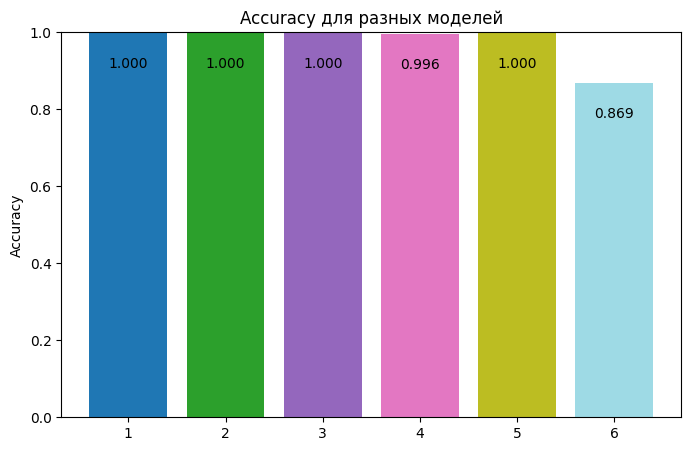

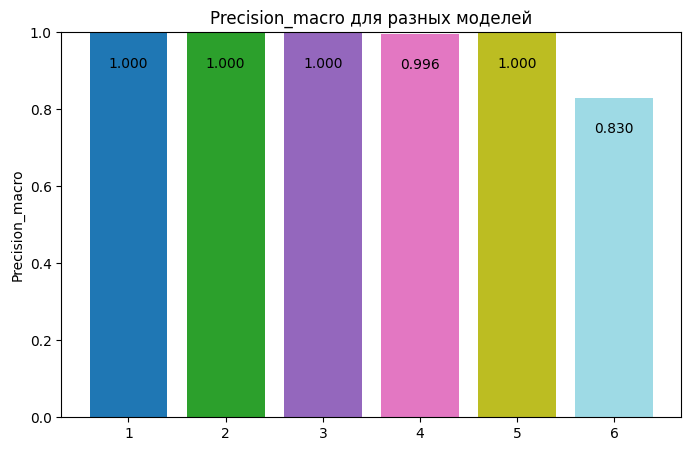

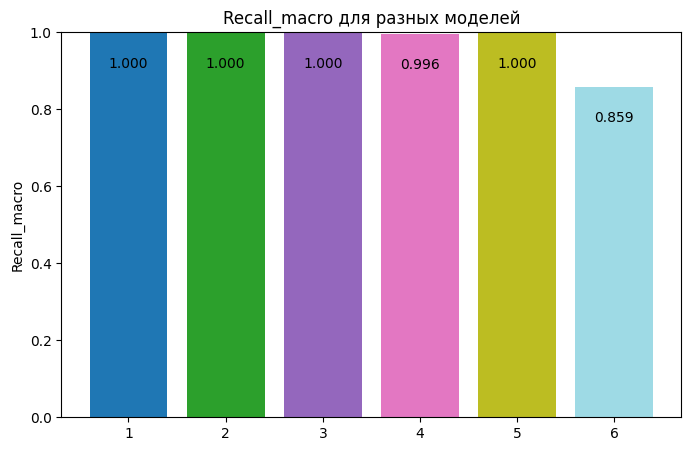

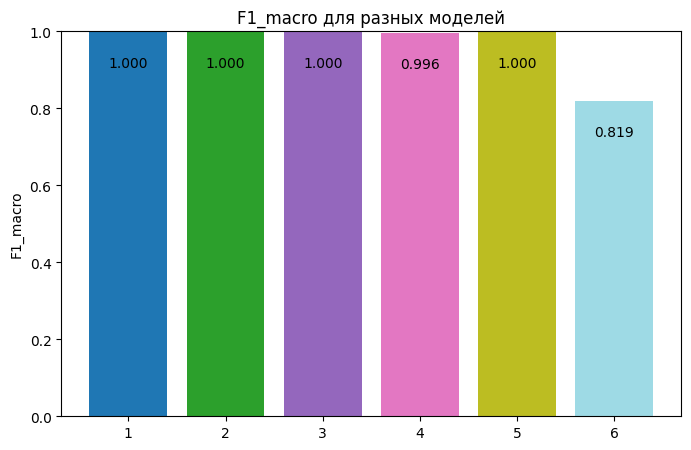

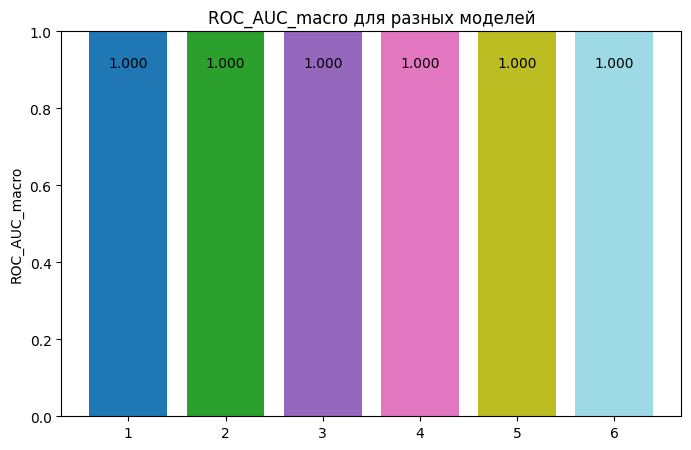

In [ ]:

print( metrics_table_my)

metrics_names = ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'ROC_AUC_macro']

for metric in metrics_names:
    values = metrics_table_my[metric]
    models = metrics_table_my['Model']
    x = np.arange(len(models))
    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

    plt.figure(figsize=(8, 5))
    plt.bar(x, values, color=colors)
    plt.xticks(x, models)
    plt.ylabel(metric)
    plt.ylim(0, 1)  
    plt.title(f'{metric} для разных моделей')
    for i, v in enumerate(values):
        plt.text(x[i], v - 0.1, f"{v:.3f}", ha='center', va='bottom')
    plt.show()

Теперь опишем представленные диаграммы.

Снизу у нас отражен номер эксперимента. 
1- исходная конфигурация нейронной сети: 2 слоя, функции активации - relu, эпохи - 5, батчи - 8.
2 - изменение числа батчей c 8 до 16.
3 - изменение числа эпох с 5 до 10.
4 - изменение числа нейронов с 64 до 32.
5 - изменение числа слоев с 2 до 1.
6 - изменение функций активации с relu на sigmoida.

Выше представлены все основные метрики для каждой конфигурации нейронной сети.

Исходя из метрик, можно сделать вывод, что конфигурации 1,2,3,5 имеют полностью одинаковые метрики вновь равные 1.

Конфигурация 4 с меньшим числом нейронов имеет метрики не меньше 0,996. Можно сделать вывод, что модель также адекватна; она с хорошей точностью классифицирует все объекты нашего датасета.

Конфигурация 6 имеет метрики не превышающие 0,87, кромер ROC_AUC.  Здесь мы меняли функцию активации. При этом, значение accuracy снизилось на 0,131; precision на 0,170; recall на 0,141 ;f1-score на 0,181. Очевидно, что для данного набора данных функция relu подходит лучше. Видно, что sigmoida хуже подходит для многослойных сетей с большим количеством нейронов